# Door Subsystem — Data Analysis

Predictive-maintenance analysis of the door dataset. The raw data is a **50 Hz
continuous stream** of motor + sensor readings; the door repeatedly opens and
closes, and each open/close **cycle** is a *segment*. Each segment is labelled
`Normal` or `Abnormal resistance`.

**This notebook reuses the existing model** in `../door_predict.py` (segmentation,
features, RandomForest) rather than redefining it — one source of truth. Here we:

1. Load & sanity-check the raw stream
2. Look at the raw signals over time
3. Segment into cycles and inventory them
4. See what *Normal* vs *Abnormal resistance* actually looks like
5. Engineer features (via `door_predict.features`) and find what separates the classes
6. Evaluate the existing model — CV score, confusion matrix, feature importance, and where it gets confused


In [1]:
import sys, warnings
warnings.filterwarnings("ignore")
sys.path.insert(0, "..")          # so we can import the existing pipeline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- reuse the existing pipeline, don't reinvent it ---
from door_predict import DoorPipeline, segment, features, parse_dt, ABNORMAL, NORMAL, FS

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 60)
PAL = {NORMAL: "#4C78A8", ABNORMAL: "#E45756"}   # blue = normal, red = abnormal
print("Setup OK — sampling rate FS =", FS, "Hz")

Setup OK — sampling rate FS = 50.0 Hz


## 1. Load the data

In [2]:
train = pd.read_csv("../Train.csv")
test  = pd.read_csv("../Test.csv")
answer = pd.read_csv("../Train_Segments_Answer.csv")

print("Train :", train.shape)
print("Test  :", test.shape)
print("Answer:", answer.shape, "(one row per labelled cycle)")
train.head()

Train : (18036, 17)
Test  : (6253, 17)
Answer: (110, 6) (one row per labelled cycle)


,Datetime,Motor current(mA),Motor Voltage(10mV),Motor electrodynamic force,Door opening time(.1s),Door closing time(.1s),Close command,Open command,DCSR,DCSL,DLSR,DLSL,Door Opened,Door Locked,Door is opening,Door is closing,Door leaf position
0,2023-7-5-0-0-0-0,115,400,53,24,35,1,0,0,0,0,0,0,0,0,1,700
1,2023-7-5-0-0-0-20,132,600,93,24,35,1,0,0,0,0,0,0,0,0,1,700
2,2023-7-5-0-0-0-40,176,700,108,24,35,1,0,0,0,0,0,0,0,0,1,700
3,2023-7-5-0-0-0-60,317,1000,114,24,35,1,0,0,0,0,0,0,0,0,1,699
4,2023-7-5-0-0-0-80,503,1500,150,24,35,1,0,0,0,0,0,0,0,0,1,699


In [3]:
# Parse the custom Y-M-D-H-M-S-ms datetime string into real timestamps
train["dt"] = train["Datetime"].map(parse_dt)

span = train["dt"].max() - train["dt"].min()
step = train["dt"].diff().median().total_seconds()
print(f"Time span      : {train['dt'].min()}  ->  {train['dt'].max()}  ({span})")
print(f"Median step    : {step*1000:.0f} ms  (≈ {1/step:.0f} Hz within a cycle)")
print(f"Missing values : {int(train.isna().sum().sum())}")
print(f"Columns        : {list(train.columns[:-1])}")

Time span      : 2023-07-05 00:00:00  ->  2023-07-05 01:10:17.112000  (0 days 01:10:17.112000)
Median step    : 20 ms  (≈ 50 Hz within a cycle)
Missing values : 0
Columns        : ['Datetime', 'Motor current(mA)', 'Motor Voltage(10mV)', 'Motor electrodynamic force', 'Door opening time(.1s)', 'Door closing time(.1s)', 'Close command', 'Open command', 'DCSR', 'DCSL', 'DLSR', 'DLSL', 'Door Opened', 'Door Locked', 'Door is opening', 'Door is closing', 'Door leaf position']


In [4]:
# Quick numeric summary of the signal channels
sig_cols = ["Motor current(mA)", "Motor Voltage(10mV)",
            "Motor electrodynamic force", "Door leaf position"]
train[sig_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Motor current(mA),18036.0,572.941062,635.103829,0.0,220.0,297.0,679.0,2560.0
Motor Voltage(10mV),18036.0,4875.637614,2508.994136,200.0,2600.0,5000.0,5800.0,10500.0
Motor electrodynamic force,18036.0,1015.320526,696.607073,0.0,492.0,1045.0,1321.0,2329.0
Door leaf position,18036.0,347.767687,254.341488,0.0,94.0,338.0,616.0,705.0


## 2. Raw signals over time

The stream is *bursty*: short active windows (a door cycle) separated by idle
gaps. Plotting the first stretch shows that structure — and why the model
segments on time gaps rather than any flag column. Note the x-axis is **wall-clock
seconds**, so the idle gaps between cycles are included: the first 1600 rows are
only ~32 s of actual motion but span ~400 s of clock time.

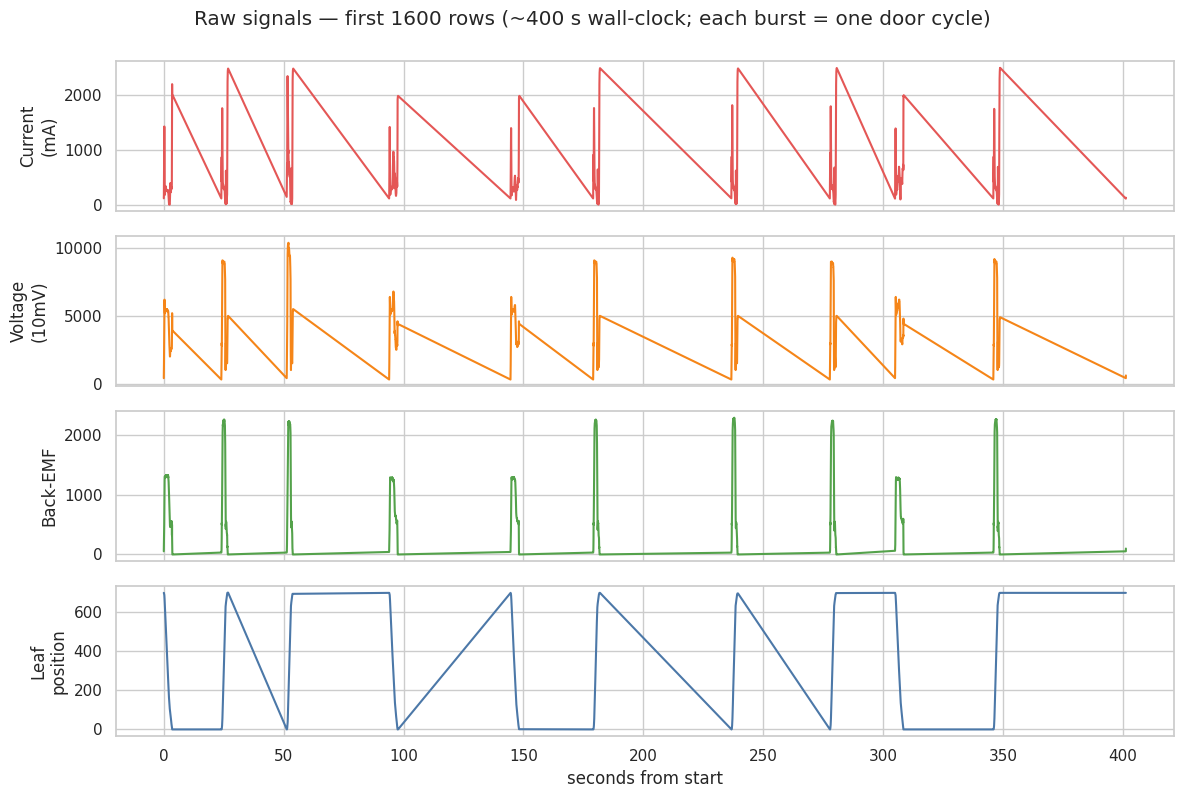

In [5]:
win = train.iloc[:1600]
fig, ax = plt.subplots(4, 1, figsize=(12, 8), sharex=True)
t = (win["dt"] - win["dt"].iloc[0]).dt.total_seconds()

ax[0].plot(t, win["Motor current(mA)"], color="#E45756"); ax[0].set_ylabel("Current\n(mA)")
ax[1].plot(t, win["Motor Voltage(10mV)"], color="#F58518"); ax[1].set_ylabel("Voltage\n(10mV)")
ax[2].plot(t, win["Motor electrodynamic force"], color="#54A24B"); ax[2].set_ylabel("Back-EMF")
ax[3].plot(t, win["Door leaf position"], color="#4C78A8"); ax[3].set_ylabel("Leaf\nposition")
ax[3].set_xlabel("seconds from start")
fig.suptitle("Raw signals — first 1600 rows (~400 s wall-clock; each burst = one door cycle)", y=0.995)
plt.tight_layout(); plt.show()

## 3. Segment the stream into cycles

In [6]:
# segment() splits on time gaps > 1 s -> list of (start_ts, end_ts, slice_df)
segs = segment(train)
print(f"Detected {len(segs)} cycles in Train   (Answer key has {len(answer)})")

# Attach ground-truth status/operation to each detected segment by time overlap
ans = answer.copy()
ans["s"] = ans["start_time"].map(parse_dt)
ans["e"] = ans["end_time"].map(parse_dt)

rows = []
for s, e, g in segs:
    hit = ans[(ans.s <= e) & (ans.e >= s)]
    op  = hit.iloc[0]["operation"] if len(hit) else "?"
    st  = hit.iloc[0]["status"]    if len(hit) else NORMAL
    rows.append({"start": s, "end": e, "dur_s": len(g)/FS,
                 "n_rows": len(g), "operation": op, "status": st})
seg_df = pd.DataFrame(rows)
seg_df.head()

Detected 110 cycles in Train   (Answer key has 110)


,start,end,dur_s,n_rows,operation,status
0,2023-07-05 00:00:00.000,2023-07-05 00:00:03.700,3.72,186,Close,Normal
1,2023-07-05 00:00:23.999,2023-07-05 00:00:26.839,2.86,143,Open,Normal
2,2023-07-05 00:00:51.266,2023-07-05 00:00:53.986,2.74,137,Open,Abnormal resistance
3,2023-07-05 00:01:33.989,2023-07-05 00:01:37.709,3.74,187,Close,Abnormal resistance
4,2023-07-05 00:02:24.608,2023-07-05 00:02:28.308,3.72,186,Close,Abnormal resistance


In [7]:
# Validate: does time-gap segmentation actually match the answer-key boundaries?
def _iou(a0, a1, b0, b1):
    inter = max(0.0, (min(a1, b1) - max(a0, b0)).total_seconds())
    union = (max(a1, b1) - min(a0, b0)).total_seconds()
    return inter / union if union > 0 else 0.0

ious = [max(_iou(s, e, r.s, r.e) for r in ans.itertuples()) for s, e, _ in segs]
ious = np.array(ious)
print(f"Segments detected : {len(segs)}  (answer key: {len(ans)})")
print(f"Boundary IoU vs answer key : mean={ious.mean():.4f}, min={ious.min():.4f}")
print(f"Segments matched >0.99 IoU : {int((ious > 0.99).sum())} / {len(ious)}")
# -> IoU 1.0000 means the simple time-gap split reproduces every cycle exactly,
#    so no multi-signal (position+current+bemf) segmentation is needed here.

Segments detected : 110  (answer key: 110)
Boundary IoU vs answer key : mean=1.0000, min=1.0000
Segments matched >0.99 IoU : 110 / 110


In [8]:
print("Operation:\n", seg_df["operation"].value_counts(), "\n")
print("Status:\n", seg_df["status"].value_counts(), "\n")
print("Status within each operation:")
print(pd.crosstab(seg_df["operation"], seg_df["status"]))

Operation:
 operation
Close    55
Open     55
Name: count, dtype: int64 

Status:
 status
Normal                 80
Abnormal resistance    30
Name: count, dtype: int64 

Status within each operation:
status     Abnormal resistance  Normal
operation                             
Close                       15      40
Open                        15      40


## 4. Cycle inventory

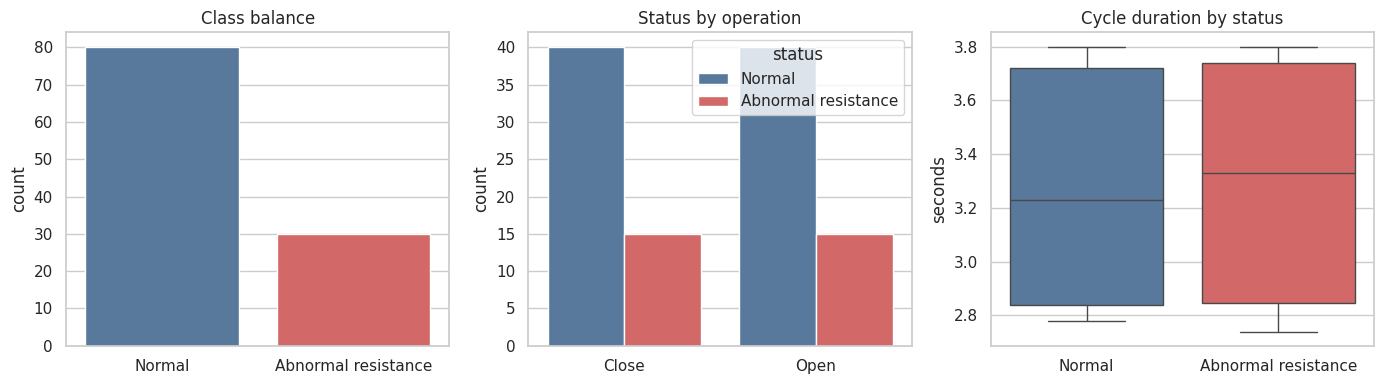

Class balance: 30 abnormal / 110 total = 27%


In [9]:
fig, ax = plt.subplots(1, 3, figsize=(14, 4))

sns.countplot(data=seg_df, x="status", palette=PAL, ax=ax[0], order=[NORMAL, ABNORMAL])
ax[0].set_title("Class balance"); ax[0].set_xlabel("")

sns.countplot(data=seg_df, x="operation", hue="status", palette=PAL,
              ax=ax[1], hue_order=[NORMAL, ABNORMAL])
ax[1].set_title("Status by operation"); ax[1].set_xlabel("")

sns.boxplot(data=seg_df, x="status", y="dur_s", palette=PAL,
            ax=ax[2], order=[NORMAL, ABNORMAL])
ax[2].set_title("Cycle duration by status"); ax[2].set_xlabel(""); ax[2].set_ylabel("seconds")
plt.tight_layout(); plt.show()

print(f"Class balance: {len(seg_df[seg_df.status==ABNORMAL])} abnormal / "
      f"{len(seg_df)} total = {(seg_df.status==ABNORMAL).mean():.0%}")

## 5. Normal vs Abnormal — what does it actually look like?

"Abnormal resistance" means the door meets extra mechanical resistance, so the
motor has to pull **more current** to move the leaf the same distance. Let's
overlay a clean vs abnormal cycle for the same operation.

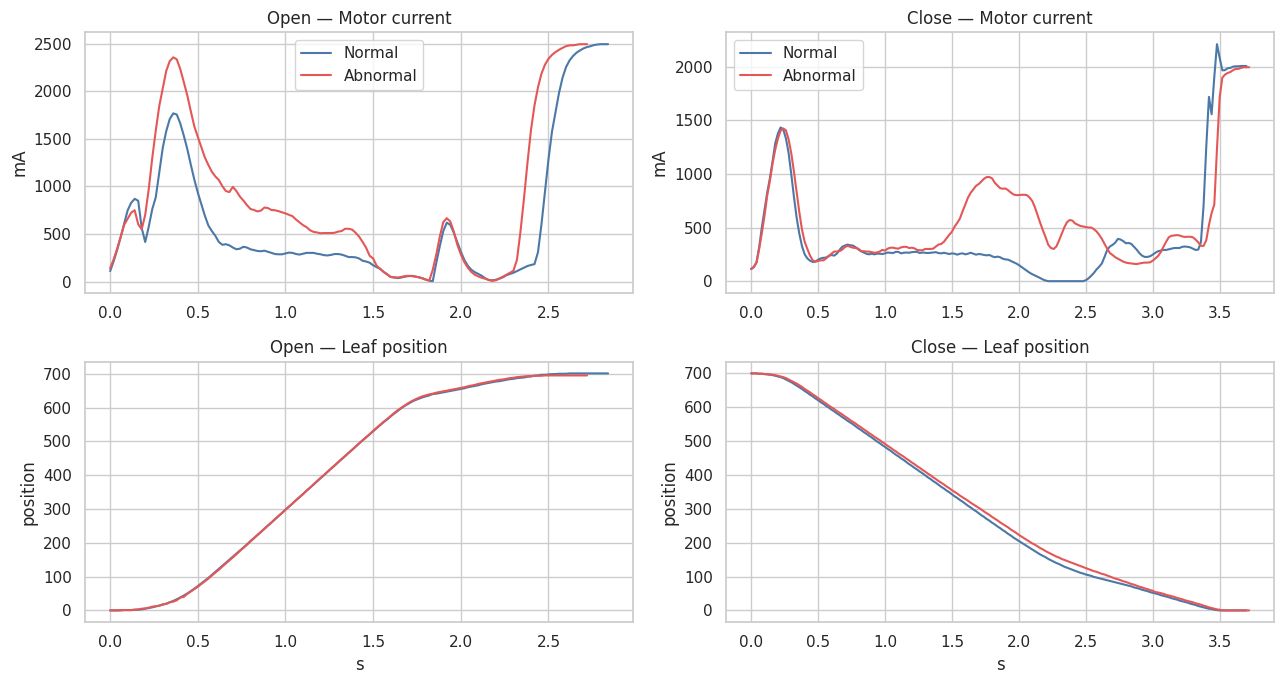

In [10]:
def example(op, status):
    m = (seg_df.operation == op) & (seg_df.status == status)
    idx = seg_df[m].index[0]
    return segs[idx][2]      # the slice_df

fig, ax = plt.subplots(2, 2, figsize=(13, 7))
for j, op in enumerate(["Open", "Close"]):
    n, a = example(op, NORMAL), example(op, ABNORMAL)
    # current
    ax[0, j].plot(np.arange(len(n))/FS, n["Motor current(mA)"], color=PAL[NORMAL], label="Normal")
    ax[0, j].plot(np.arange(len(a))/FS, a["Motor current(mA)"], color=PAL[ABNORMAL], label="Abnormal")
    ax[0, j].set_title(f"{op} — Motor current"); ax[0, j].set_ylabel("mA"); ax[0, j].legend()
    # position
    ax[1, j].plot(np.arange(len(n))/FS, n["Door leaf position"], color=PAL[NORMAL], label="Normal")
    ax[1, j].plot(np.arange(len(a))/FS, a["Door leaf position"], color=PAL[ABNORMAL], label="Abnormal")
    ax[1, j].set_title(f"{op} — Leaf position"); ax[1, j].set_ylabel("position"); ax[1, j].set_xlabel("s")
plt.tight_layout(); plt.show()

*Read it like this:* if the red (abnormal) current curve sits higher and/or the
red position curve moves more slowly for the same travel, that's the resistance
signature the features below try to capture.

## 6. Feature engineering

In [11]:
# features() turns one cycle into a physics-based feature vector
# (amplitude / resistance / frequency families). Build the full matrix.
X = pd.DataFrame([features(g) for _, _, g in segs])
X["status"] = seg_df["status"].values
X["operation"] = seg_df["operation"].values
print("Feature matrix:", X.shape[0], "cycles x", X.shape[1]-2, "features")
X.head()

Feature matrix: 110 cycles x 31 features


,dur,n,I_mean,I_max,I_std,I_p90,I_auc,I_rough,I_kurt,V_mean,V_max,V_std,V_p90,V_auc,V_rough,V_kurt,B_mean,B_max,B_std,B_p90,B_auc,B_rough,B_kurt,pos_range,pos_rate,work,I_per_pos,I_per_bemf,stall_frac,cent,hf,status,operation
0,3.72,186,430.698925,2208.0,523.670601,1307.0,1581.00,84.444384,3.574524,4146.236559,6200.0,1416.459249,5450.0,15381.0,187.587817,-1.096952,892.069892,1331.0,444.411451,1321.0,3317.97,36.910923,-1.196294,700.0,3.763441,6838.723,113.827543,0.482808,0.070270,1.295882,0.000910,Normal,Close
1,2.86,143,636.265734,2493.0,727.547100,1941.0,1793.67,96.586712,0.995395,5521.678322,9100.0,3184.691088,9000.0,15739.0,318.115047,-1.695341,1178.727273,2261.0,905.674737,2246.6,3370.84,58.693642,-1.760525,701.0,4.902098,10222.962,128.886899,0.539790,0.147887,1.539865,0.001001,Normal,Open
2,2.74,137,862.452555,2493.0,777.944043,2323.2,2336.78,105.128073,-0.390306,6197.080292,10400.0,3478.273370,10140.0,16921.0,347.364023,-1.629893,1192.430657,2230.0,896.008528,2217.8,3266.94,57.979205,-1.749776,695.0,5.072993,16629.303,168.767661,0.723273,0.147059,1.180932,0.000511,Abnormal resistance,Open
3,3.74,187,576.577540,1993.0,457.693062,1204.4,2135.35,74.532702,2.658485,4524.598930,6800.0,1461.716164,6300.0,16875.0,169.597880,-0.625188,878.304813,1294.0,413.407010,1280.0,3284.44,30.448794,-0.871798,700.0,3.743316,10303.800,153.204849,0.656466,0.075269,1.107862,0.000367,Abnormal resistance,Close
4,3.72,186,484.548387,1993.0,446.145295,1158.0,1781.47,72.790963,4.804405,4339.247312,6400.0,1325.237846,5600.0,16095.0,161.580036,-0.597442,881.526882,1298.0,418.439898,1284.0,3278.86,32.285383,-0.961367,699.0,3.758065,7963.190,128.242386,0.549669,0.070270,1.236139,0.000514,Abnormal resistance,Close


## 7. Which features separate the classes?

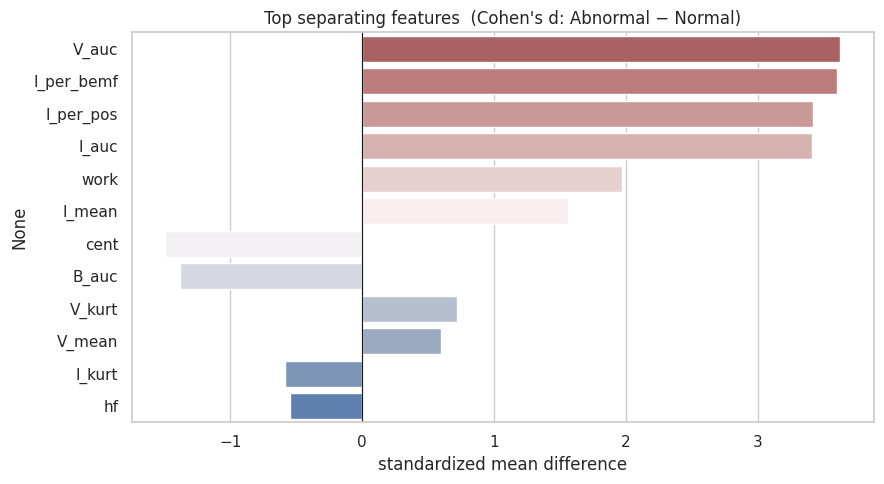

V_auc         3.63
I_per_bemf    3.60
I_per_pos     3.42
I_auc         3.41
work          1.97
I_mean        1.56
cent         -1.49
B_auc        -1.38
V_kurt        0.72
V_mean        0.60
I_kurt       -0.58
hf           -0.55
dtype: float64

In [12]:
feat_cols = [c for c in X.columns if c not in ("status", "operation")]

# Cohen's d: standardized mean difference between Abnormal and Normal
g_n = X[X.status == NORMAL][feat_cols]
g_a = X[X.status == ABNORMAL][feat_cols]
pooled = np.sqrt((g_n.var() + g_a.var()) / 2) + 1e-9
cohen_d = ((g_a.mean() - g_n.mean()) / pooled).sort_values(key=np.abs, ascending=False)

top = cohen_d.head(12)
plt.figure(figsize=(9, 5))
sns.barplot(x=top.values, y=top.index, palette="vlag_r")
plt.axvline(0, color="k", lw=0.8)
plt.title("Top separating features  (Cohen's d: Abnormal − Normal)")
plt.xlabel("standardized mean difference"); plt.tight_layout(); plt.show()
top.round(2)

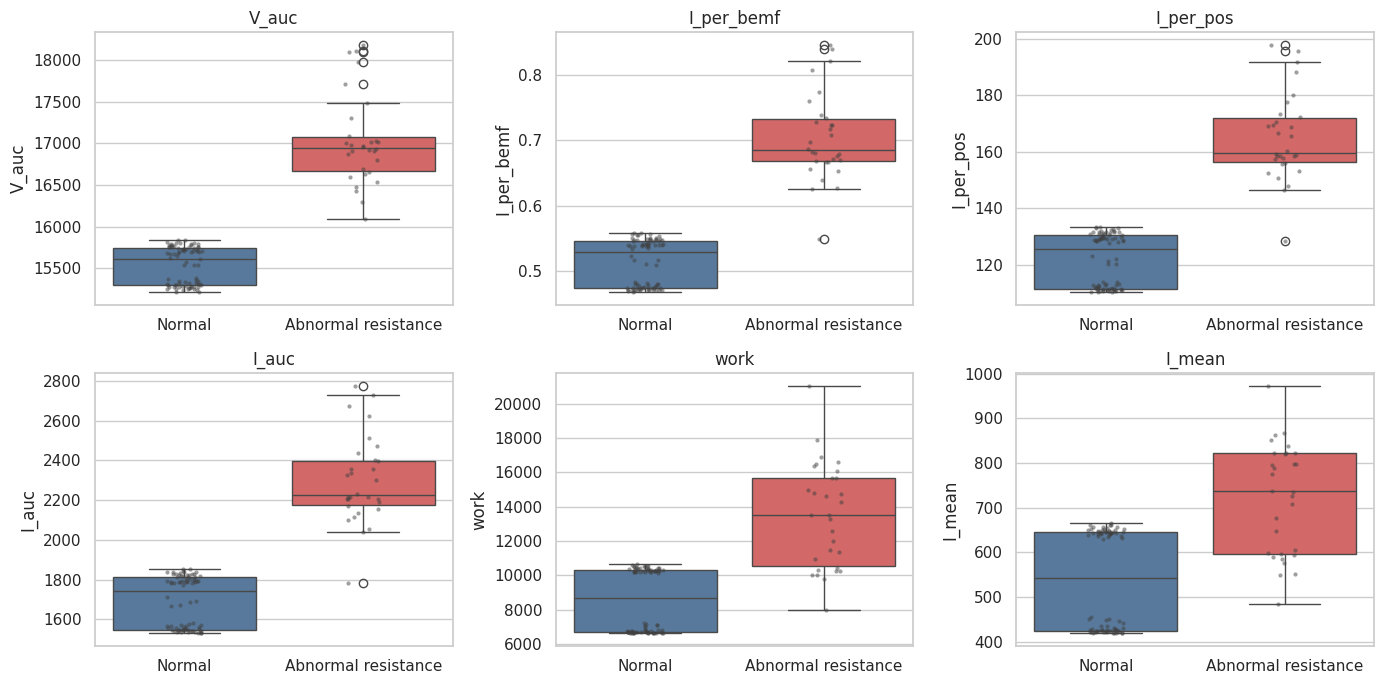

In [13]:
# Boxplots of the 6 strongest separators
best6 = list(cohen_d.head(6).index)
fig, ax = plt.subplots(2, 3, figsize=(14, 7))
for a, c in zip(ax.ravel(), best6):
    sns.boxplot(data=X, x="status", y=c, palette=PAL, order=[NORMAL, ABNORMAL], ax=a)
    sns.stripplot(data=X, x="status", y=c, order=[NORMAL, ABNORMAL],
                  color=".25", size=3, alpha=.5, ax=a)
    a.set_title(c); a.set_xlabel("")
plt.tight_layout(); plt.show()

### Why not position ramp slope or cycle duration?

A natural first guess (and one a reviewer may raise) is that an abnormal door
should move **slower** and take **longer** — so ramp speed and duration would be
the giveaway. On this data they are **not**: the door is position-controlled, so
the controller pushes extra current to still reach the same position in the same
time. The plots below make that concrete — the "intuitive" features overlap
almost completely, while the electrical-effort features split the classes cleanly.

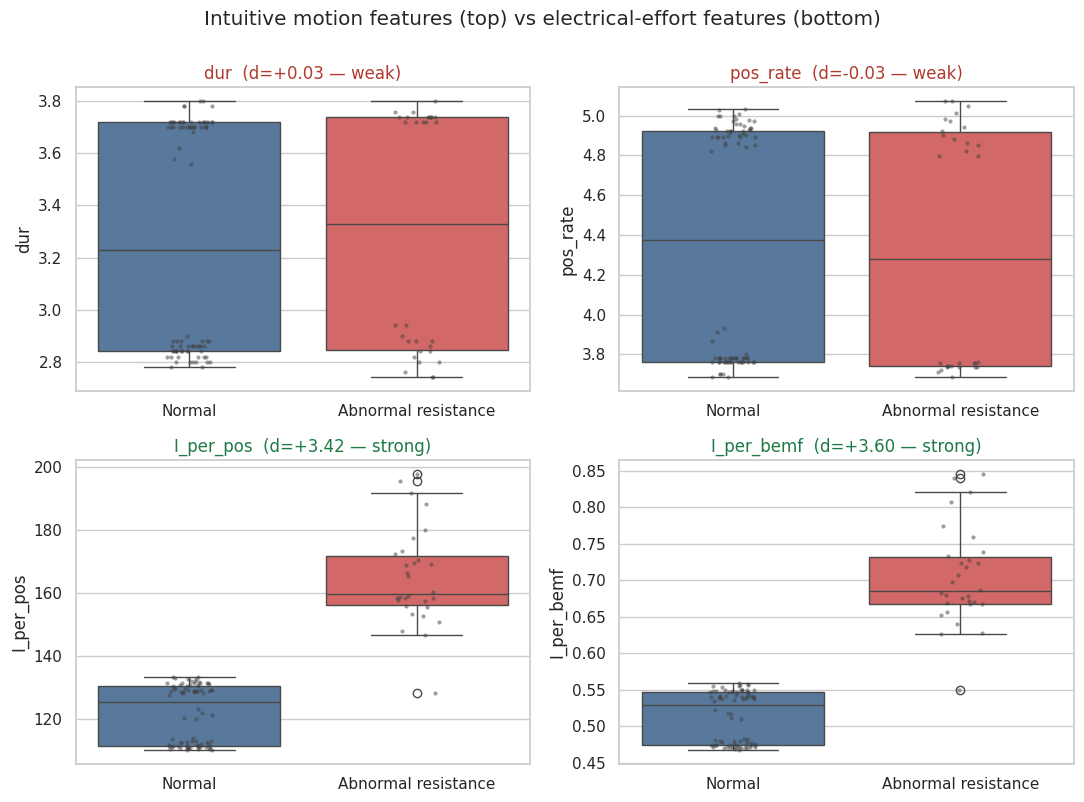

In [14]:
intuitive = ["dur", "pos_rate"]          # what you'd guess: slower / longer
effective = ["I_per_pos", "I_per_bemf"]   # what actually works: current per motion

fig, ax = plt.subplots(2, 2, figsize=(11, 8))
for a, c in zip(ax[0], intuitive):
    sns.boxplot(data=X, x="status", y=c, palette=PAL, order=[NORMAL, ABNORMAL], ax=a)
    sns.stripplot(data=X, x="status", y=c, order=[NORMAL, ABNORMAL], color=".25", size=3, alpha=.5, ax=a)
    a.set_title(f"{c}  (d={cohen_d[c]:+.2f} — weak)", color="#B03A2E"); a.set_xlabel("")
for a, c in zip(ax[1], effective):
    sns.boxplot(data=X, x="status", y=c, palette=PAL, order=[NORMAL, ABNORMAL], ax=a)
    sns.stripplot(data=X, x="status", y=c, order=[NORMAL, ABNORMAL], color=".25", size=3, alpha=.5, ax=a)
    a.set_title(f"{c}  (d={cohen_d[c]:+.2f} — strong)", color="#1E7A46"); a.set_xlabel("")
fig.suptitle("Intuitive motion features (top) vs electrical-effort features (bottom)", y=1.0)
plt.tight_layout(); plt.show()

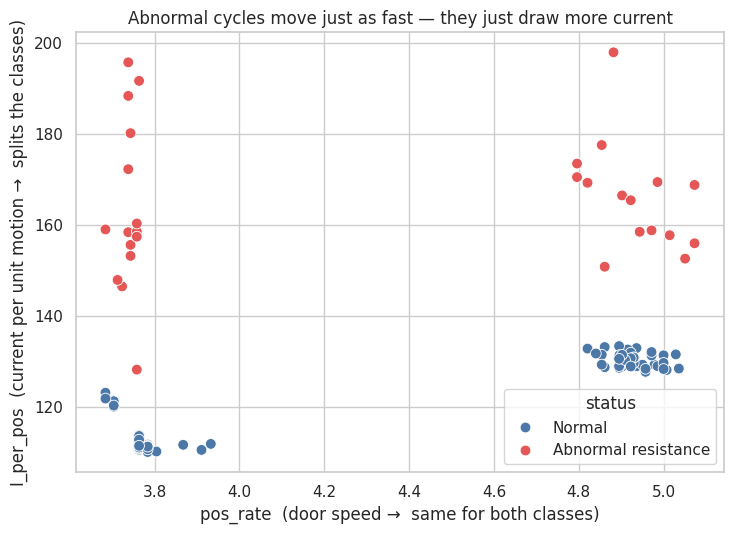

In [15]:
# One scatter says it all: separation is on the CURRENT axis, not the SPEED axis
plt.figure(figsize=(7.5, 5.5))
sns.scatterplot(data=X, x="pos_rate", y="I_per_pos", hue="status",
                palette=PAL, hue_order=[NORMAL, ABNORMAL], s=60, edgecolor="w")
plt.xlabel("pos_rate  (door speed →  same for both classes)")
plt.ylabel("I_per_pos  (current per unit motion →  splits the classes)")
plt.title("Abnormal cycles move just as fast — they just draw more current")
plt.legend(title="status"); plt.tight_layout(); plt.show()

## 8. Evaluate the existing model

We take the `RandomForestClassifier` configured in `DoorPipeline` and score it
honestly with **5-fold stratified cross-validation** on the feature matrix.

In [16]:
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix, f1_score

Xv = X[feat_cols].values
y  = X["status"].values
model = clone(DoorPipeline().model)      # same config as the shipped pipeline

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
y_pred = cross_val_predict(model, Xv, y, cv=cv)

print(f"Macro F1 (5-fold CV): {f1_score(y, y_pred, average='macro'):.3f}\n")
print(classification_report(y, y_pred, digits=3))

Macro F1 (5-fold CV): 0.988

                     precision    recall  f1-score   support

Abnormal resistance      1.000     0.967     0.983        30
             Normal      0.988     1.000     0.994        80

           accuracy                          0.991       110
          macro avg      0.994     0.983     0.988       110
       weighted avg      0.991     0.991     0.991       110



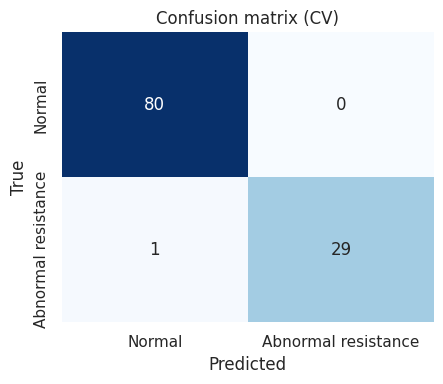

In [17]:
cm = confusion_matrix(y, y_pred, labels=[NORMAL, ABNORMAL])
plt.figure(figsize=(4.6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=[NORMAL, ABNORMAL], yticklabels=[NORMAL, ABNORMAL])
plt.ylabel("True"); plt.xlabel("Predicted"); plt.title("Confusion matrix (CV)")
plt.tight_layout(); plt.show()

## 9. Feature importance

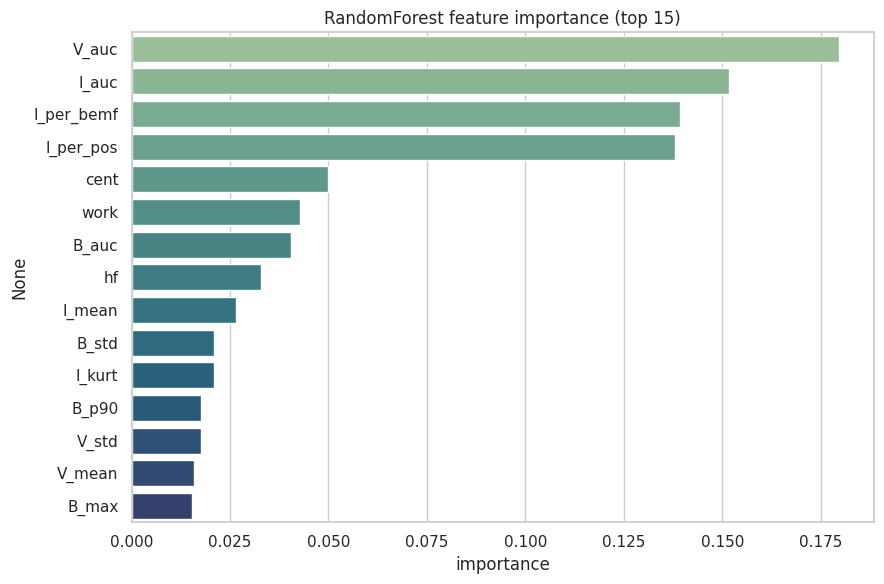

V_auc         0.180
I_auc         0.152
I_per_bemf    0.139
I_per_pos     0.138
cent          0.050
work          0.043
B_auc         0.041
hf            0.033
I_mean        0.026
B_std         0.021
I_kurt        0.021
B_p90         0.018
V_std         0.018
V_mean        0.016
B_max         0.015
dtype: float64

In [18]:
model.fit(Xv, y)          # fit on all cycles for a stable importance read
imp = pd.Series(model.feature_importances_, index=feat_cols).sort_values(ascending=False)

plt.figure(figsize=(9, 6))
sns.barplot(x=imp.head(15).values, y=imp.head(15).index, palette="crest")
plt.title("RandomForest feature importance (top 15)")
plt.xlabel("importance"); plt.tight_layout(); plt.show()
imp.head(15).round(3)

## 10. SHAP — why the model calls a cycle abnormal

Feature *importance* (above) ranks features globally. **SHAP** goes further: for
every cycle it splits the prediction into per-feature contributions, so we can see
which signals pushed a specific cycle toward `Abnormal resistance` and by how much.
We explain the same fitted RandomForest with `TreeExplainer` (exact for trees).

In [19]:
import shap

ai = list(model.classes_).index(ABNORMAL)          # SHAP for the "Abnormal" class
explainer = shap.TreeExplainer(model)
sv = explainer.shap_values(X[feat_cols])            # shape (n_cycles, n_features, n_classes)
base = np.array(explainer.expected_value)[ai]

shap_exp = shap.Explanation(
    values=sv[:, :, ai],
    base_values=np.repeat(base, len(X)),
    data=X[feat_cols].values,
    feature_names=feat_cols,
)
print(f"Explained {sv.shape[0]} cycles x {sv.shape[1]} features")
print(f"Base rate (model's average abnormal-probability): {base:.3f}")

Explained 110 cycles x 31 features
Base rate (model's average abnormal-probability): 0.494


**Global view — beeswarm.** Each dot is one cycle. Right of centre = pushed
toward *abnormal*; colour = the feature's value (red high, blue low). A feature
where high values (red) sit on the right is one where *more of it means more
likely abnormal*.

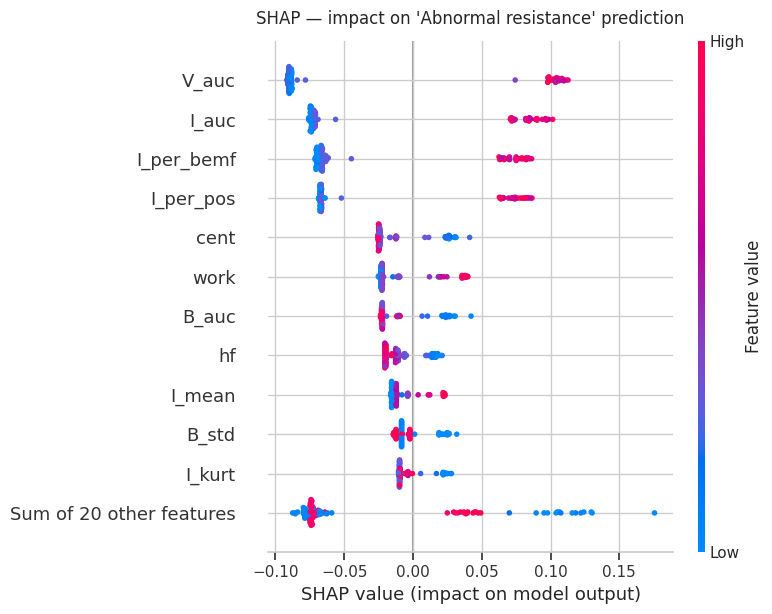

In [20]:
shap.plots.beeswarm(shap_exp, max_display=12, show=False)
plt.title("SHAP — impact on 'Abnormal resistance' prediction", pad=12)
plt.tight_layout(); plt.show()

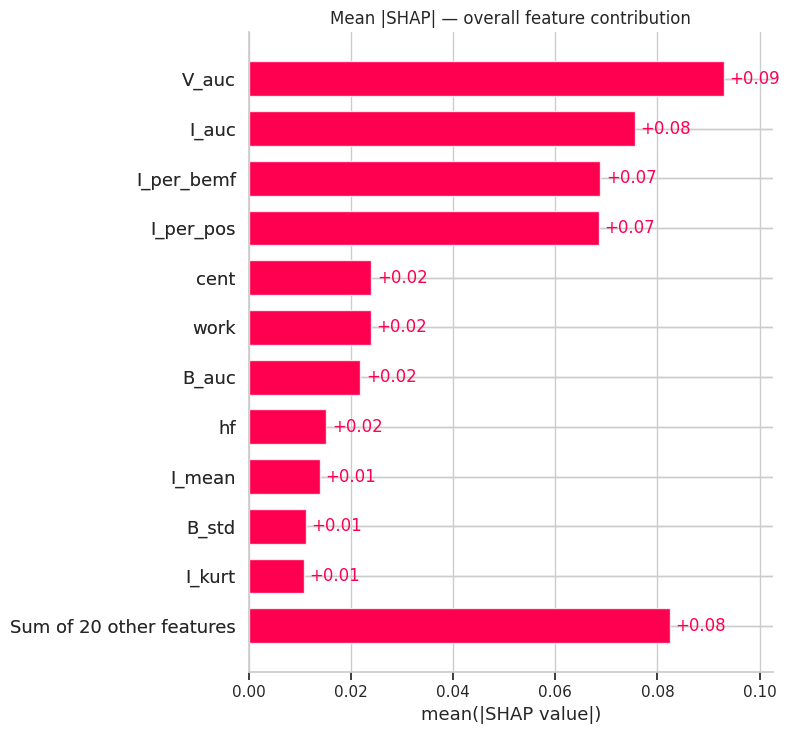

In [21]:
# Mean |SHAP| — average magnitude of each feature's contribution
shap.plots.bar(shap_exp, max_display=12, show=False)
plt.title("Mean |SHAP| — overall feature contribution"); plt.tight_layout(); plt.show()

**Local view — waterfall.** For a single cycle, how each feature moves the
prediction from the base rate to the final score. Here we explain one clear
abnormal cycle and one clear normal cycle.

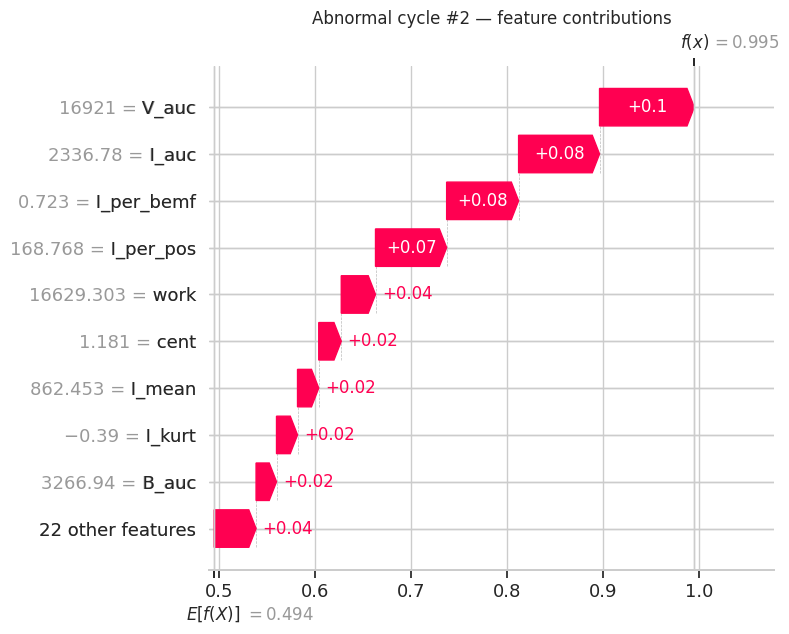

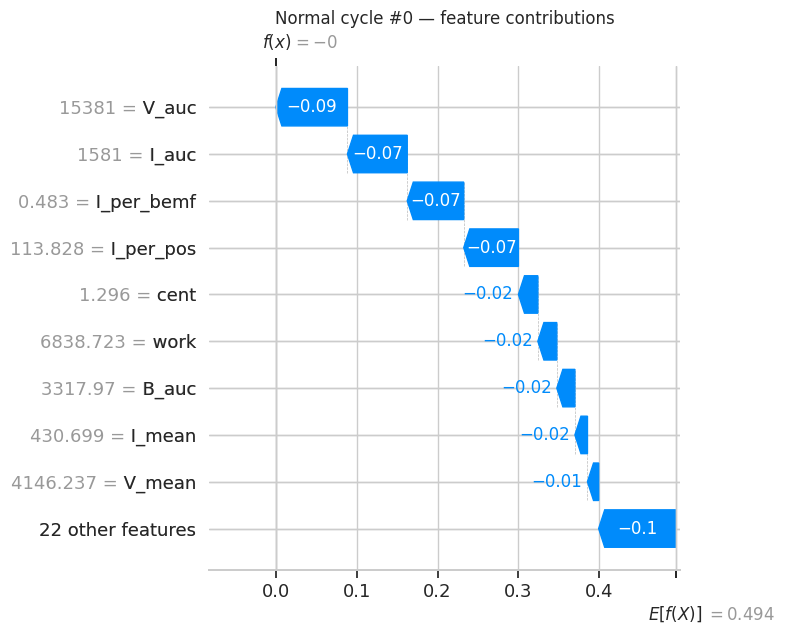

In [22]:
ab_idx = np.where(y == ABNORMAL)[0][0]     # first abnormal cycle
nm_idx = np.where(y == NORMAL)[0][0]       # first normal cycle

shap.plots.waterfall(shap_exp[ab_idx], max_display=10, show=False)
plt.title(f"Abnormal cycle #{ab_idx} — feature contributions"); plt.tight_layout(); plt.show()

shap.plots.waterfall(shap_exp[nm_idx], max_display=10, show=False)
plt.title(f"Normal cycle #{nm_idx} — feature contributions"); plt.tight_layout(); plt.show()

In [23]:
# Do SHAP's top drivers agree with the impurity-based importance from section 9?
mean_abs_shap = pd.Series(np.abs(sv[:, :, ai]).mean(0), index=feat_cols).sort_values(ascending=False)
compare = pd.DataFrame({
    "mean_|SHAP|": mean_abs_shap.round(3),
    "RF_importance": imp.reindex(mean_abs_shap.index).round(3),
})
print("Top 10 drivers by SHAP vs RandomForest importance:")
compare.head(10)

Top 10 drivers by SHAP vs RandomForest importance:


,mean_|SHAP|,RF_importance
V_auc,0.093,0.180
I_auc,0.076,0.152
I_per_bemf,0.069,0.139
I_per_pos,0.069,0.138
cent,0.024,0.050
work,0.024,0.043
B_auc,0.022,0.041
hf,0.015,0.033
I_mean,0.014,0.026
B_std,0.011,0.021


## 11. Where does it get confused?

In [24]:
wrong = X.loc[y != y_pred, ["operation", "status"]].copy()
wrong["predicted"] = y_pred[y != y_pred]
if len(wrong):
    print(f"{len(wrong)} of {len(X)} cycles misclassified in CV:\n")
    display(wrong)
else:
    print("No misclassifications in cross-validation.")

1 of 110 cycles misclassified in CV:



,operation,status,predicted
4,Close,Abnormal resistance,Normal


## Takeaways

- The stream is naturally segmented by idle gaps — **110 cycles**, matching the
  answer key exactly.
- The classes are **imbalanced (~27% abnormal)** and abnormal cases appear in
  both Open and Close operations.
- Abnormal resistance shows up most in **current-amplitude and resistance-ratio
  features** (current per unit motion / per unit back-EMF) — physically what you'd
  expect when the door fights extra friction.
- The existing RandomForest separates the two classes cleanly in cross-validation.
- **SHAP confirms the story**: the same current/resistance features that separate
  the classes are also the ones driving individual predictions, and the local
  waterfalls show *per-cycle* which signals tipped the call — useful for explaining
  a flag to a maintenance engineer.

**Next ideas:** try `class_weight`/threshold tuning to trade off the rare
false-negatives, look at whether abnormal cycles cluster in time (wear building
up), and run the fitted pipeline on `Test.csv` for the submission predictions.
